# Bias-Aware Community Detection on Twitter (Academic Version)

**Objective.** This notebook evaluates a bias-aware community detection heuristic (Enhanced Louvain with Bias) on the Twitter Political Bias dataset. We replicate the methodological structure used in the FACTOID notebook, adapting it to the Twitter setting and focusing exclusively on **partisanship** bias.

**Contributions.** (i) Clear data ingestion and validation, (ii) robust execution pipeline with informative logging, (iii) evaluation via ARI/NMI, and (iv) parameter sweep over the bias–regularization strength \(\alpha\).

**Notes.** Paths are parameterized below. No TwiBot or misinformation labels are used; only **partisanship** is considered throughout.


## 1. Environment and Paths
All imports are taken from the local `/src` package. Update file paths if needed.

In [1]:
import os, sys, json, gzip, io
from pathlib import Path

# --- Adjust this if your project root differs ---
PROJECT_ROOT = Path(os.getcwd())
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

# --- Twitter dataset paths (edit as needed) ---
DATA_DIR = PROJECT_ROOT / "TWITTER"
MEASURES_TAB = DATA_DIR / "measures.tab"
ANON_FRIENDS = DATA_DIR / "anonymized-friends.json"  # supports .json or .json.gz
ANON_SHARES  = DATA_DIR / "anonymized-shares.json"   # optional; not required for the heuristic itself

# Execution knobs
ALPHA_FIXED = 0.5
ALPHA_GRID  = [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0]

# Optional: if the underlying heuristic fails when num_communities=None,
# we will retry with a small K (e.g., K=2) as a practical fallback.
FALLBACK_K = 2

print(f"Project root: {PROJECT_ROOT}")
print(f"/src path   : {SRC_DIR}")
print(f"Data dir    : {DATA_DIR}")

Project root: d:\Projetos\bias-aware-community-detection
/src path   : d:\Projetos\bias-aware-community-detection\src
Data dir    : d:\Projetos\bias-aware-community-detection\TWITTER


## 2. Imports (Project Modules)
The notebook relies on the existing `/src` modules, without TwiBot/misinformation dependencies.

In [2]:
import pandas as pd
import networkx as nx
from typing import Dict, Any

# Local project modules
from config import *  # only if you keep some global knobs here; otherwise remove
import data_utils
import evaluation
import heuristic
import twitter_dataset
import bias_calculator

print("Imported project modules successfully.")

13:16:48 | INFO     | ✅ Logging initialized.
13:16:48 | INFO     | ⚙️ Configuration loaded successfully.
13:16:48 | INFO     | 📦 Current base path: d:\Projetos\bias-aware-community-detection
13:16:48 | INFO     | α fixed = 0.5, user limit = 50,000


Imported project modules successfully.


## 3. Utility: Robust JSON Loader for Large Files
For very large `anonymized-friends.json` files, the standard `json.load` may hit parser limits on certain environments. We provide a streaming fallback that tolerates large top-level dicts.

In [3]:
def _open_textmaybe_gz(path: Path):
    path = Path(path)
    if str(path).endswith('.gz'):
        return io.TextIOWrapper(gzip.open(path, 'rb'))
    return open(path, 'r', encoding='utf-8')

def load_friends_graph_streaming(path_json: Path, limit: int = 50000) -> nx.Graph:
    """
    Streaming-safe loader for a mapping: user_id -> list_of_friend_ids.
    Builds an undirected graph where each key is a node and all its friend ids are linked.
    Only used if the canonical loader raises a JSONDecodeError.
    """
    import re

    G = nx.Graph()
    with _open_textmaybe_gz(path_json) as f:
        text = f.read().strip()
    if text.startswith('{') and text.endswith('}'):
        text = text[1:-1].strip()

    # Very simple splitter at top-level commas between key-blocks.
    # Assumes the file is a flat dict {"uid": [...], "uid2": [...], ...}
    # and that inner lists don't contain nested dicts with unmatched braces.
    parts = []
    buf, depth = [], 0
    for ch in text:
        buf.append(ch)
        if ch == '[':
            depth += 1
        elif ch == ']':
            depth -= 1
        elif ch == ',' and depth == 0:
            parts.append(''.join(buf[:-1]).strip())
            buf = []
    if buf:
        parts.append(''.join(buf).strip())

    import json
    from tqdm import tqdm
    c = 0
    for p in tqdm(parts, total=len(parts)):
        if not p:
            continue
        # Ensure each chunk is a valid JSON pair
        if ':' not in p:
            continue
        try:
            # Rewrap as a tiny dict
            kv_text = '{' + p + '}'
            kv = json.loads(kv_text)
        except Exception:
            continue
        for uid, friends in kv.items():
            try:
                uid_int = int(uid)
            except Exception:
                # keys may already be int
                uid_int = uid
            G.add_node(uid_int)
            for v in friends:
                G.add_edge(uid_int, v)
        c += 1
        if limit and c >= limit:
            break
    return G

print("Streaming loader ready.")

Streaming loader ready.


## 4. Data Loading and Sanity Checks
We load `measures.tab` (for partisanship), the friendship graph, and derive the working subgraph induced by users with known bias. Ground-truth here refers to the *reference partisanship side* used for ARI/NMI grouping (e.g., coarse polarity), not bot/misinformation labels.

In [4]:
from pathlib import Path

print("🚀 Starting Twitter dataset pipeline ...")

# 1) measures.tab
df_measures = twitter_dataset.load_measures_tab(MEASURES_TAB)
assert isinstance(df_measures, pd.DataFrame) and len(df_measures) > 0, "Empty measures.tab"
print(f"✅ measures.tab loaded: {len(df_measures):,} users")

# 2) friends graph (robust to JSONDecodeError)
try:
    G_full = twitter_dataset.load_friends_graph(ANON_FRIENDS, limit=50000)
except json.JSONDecodeError as e:
    print(f"[WARN] Falling back to streaming loader due to JSONDecodeError: {e}")
    G_full = load_friends_graph_streaming(ANON_FRIENDS, limit=50000)

print(f"📊 Full graph: |V|={G_full.number_of_nodes():,} |E|={G_full.number_of_edges():,}")

# 3) Partisanship-only bias dictionary
b_part = bias_calculator.compute_bias_from_measures(df_measures)
assert isinstance(b_part, dict) and len(b_part) > 0, "Empty bias dictionary"
print(f"✅ Bias dictionary (partisanship) for {len(b_part):,} users")

# 4) Ground truth from measures.tab (coarse side/polarity only)
gt = twitter_dataset.generate_ground_truth(df_measures)
assert isinstance(gt, dict) and len(gt) > 0, "Empty ground-truth labels"
print("✅ Ground-truth generated (partisanship-based)")

# 5) Induced subgraph over users with known bias
valid_uids = set(b_part.keys()) & set(G_full.nodes())
G = G_full.subgraph(valid_uids).copy()
print(f"🔍 Valid intersection: {len(valid_uids):,} users with bias in the graph")
print(f"📊 Final graph: |V|={G.number_of_nodes():,} |E|={G.number_of_edges():,}")

# 6) Summarize availability for clarity
nV = G.number_of_nodes()
nE = G.number_of_edges()
nb = len(b_part)
ngt = len(gt)
print(f"Twitter loaded: |V|={nV} |E|={nE}  |b|={nb}  |gt|={ngt}")
print("Note: |b| counts the bias scores available in measures.tab; |gt| counts users with a ground-truth polarity label.")

13:16:49 | INFO     | 📂 Loading user measures from d:\Projetos\bias-aware-community-detection\TWITTER\measures.tab ...
13:16:49 | INFO     | ✅ Measures loaded: 15,056 users.
13:16:49 | INFO     | 🔧 Building social graph from d:\Projetos\bias-aware-community-detection\TWITTER\anonymized-friends.json ...


🚀 Starting Twitter dataset pipeline ...
✅ measures.tab loaded: 15,056 users


100%|██████████| 15927/15927 [00:11<00:00, 1331.44it/s]
13:17:01 | INFO     | 📊 Graph built: |V|=58,216 |E|=8,809,376


📊 Full graph: |V|=58,216 |E|=8,809,376


13:17:01 | INFO     | ✅ Computed bias for 15,056 users (range = [-0.904, 0.971])


✅ Bias dictionary (partisanship) for 15,056 users


13:17:01 | INFO     | ✅ Generated ground-truth labels for 15,056 users (6,840 right-leaning, 8,216 left-leaning)


✅ Ground-truth generated (partisanship-based)
🔍 Valid intersection: 15,056 users with bias in the graph
📊 Final graph: |V|=15,056 |E|=2,544,068
Twitter loaded: |V|=15056 |E|=2544068  |b|=15056  |gt|=15056
Note: |b| counts the bias scores available in measures.tab; |gt| counts users with a ground-truth polarity label.


## 4.1 Visualização inicial da rede

Subgrafo para visualização gerado com k=15. Nº de nós: 13416


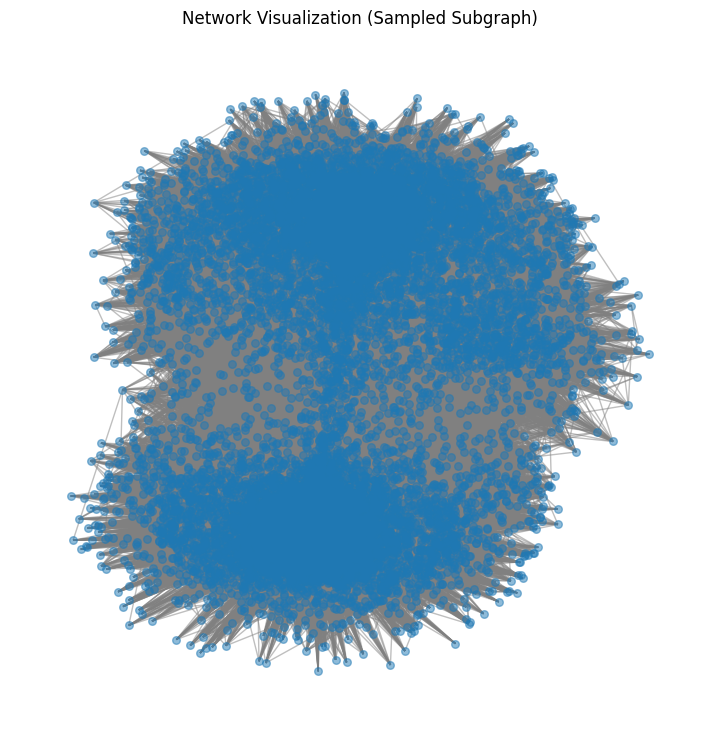

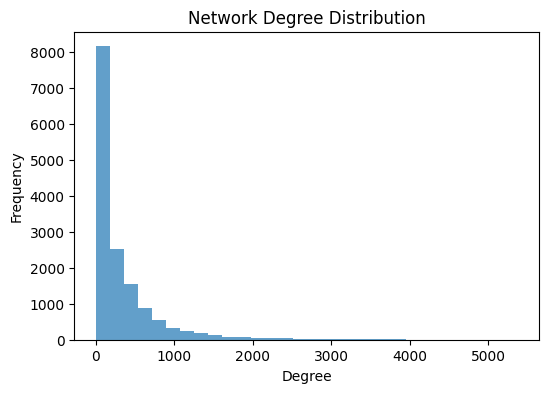

In [5]:


import matplotlib.pyplot as plt
import numpy as np

# Criamos um subgrafo baseado nos nós de maior grau para facilitar visualização
try:
    k_sub = 15  # pode ajustar dependendo da densidade
    sub = nx.k_core(G, k=k_sub)
    print(f"Subgrafo para visualização gerado com k={k_sub}. Nº de nós:", len(sub.nodes()))
except Exception:
    sub = G.subgraph(list(G.nodes())[:300])  # fallback
    print("Usando subgrafo por truncamento:", len(sub.nodes()))

# Calcular layout para visualização
pos = nx.spring_layout(sub, seed=42)

plt.figure(figsize=(7, 7))
nx.draw(sub, pos, node_size=30, edge_color="gray", alpha=0.5)
plt.title("Network Visualization (Sampled Subgraph)")
plt.show()

# --------------------------------------------
# 📈 Distribuição de graus
# --------------------------------------------
degrees = [d for _, d in G.degree()]
plt.figure(figsize=(6, 4))
plt.hist(degrees, bins=30, alpha=0.7)
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.title("Network Degree Distribution")
plt.show()


## 5. Louvain

Número de comunidades detectadas: 67
Modularidade (Q) do Louvain: 0.446092

Exemplo (10 primeiros nós):
[(65537, 0), (65538, 0), (131075, 1), (5, 0), (32775, 1), (65544, 2), (98314, 0), (131083, 0), (32780, 1), (131084, 0)]


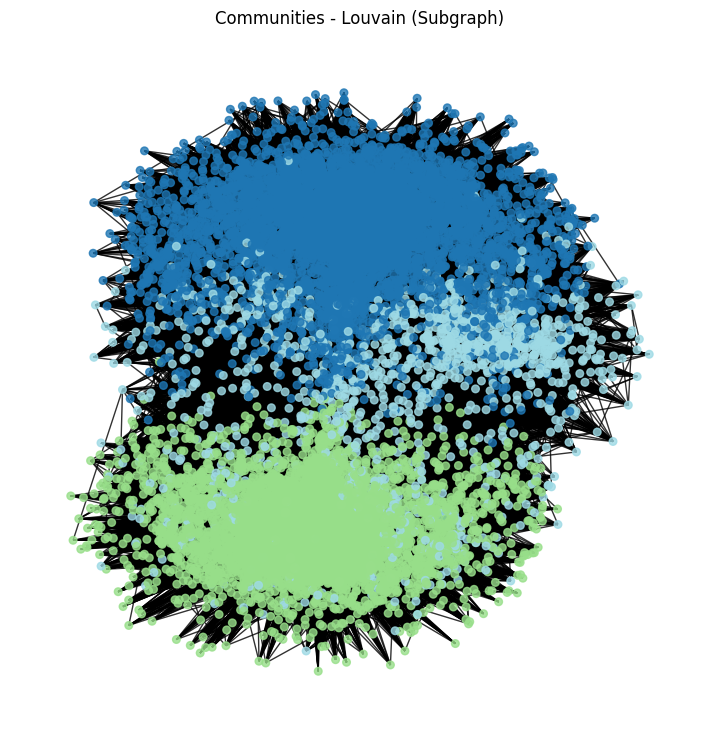

In [6]:
import networkx as nx
import community.community_louvain as louvain

# Supondo que você já tenha seu grafo G carregado
# G = ...  # seu grafo NetworkX

# Executa Louvain padrão
partition = louvain.best_partition(G)

# Número de comunidades detectadas automaticamente
num_comunidades = len(set(partition.values()))
print(f"Número de comunidades detectadas: {num_comunidades}")

# Modularidade (Q)
Q_louvain = louvain.modularity(partition, G)
print(f"Modularidade (Q) do Louvain: {Q_louvain:.6f}")

# Se quiser, pode gerar um vetor de comunidades por nó
# Exemplo: lista de tuplas (nó, comunidade)
comunidades = [(node, comm) for node, comm in partition.items()]
print("\nExemplo (10 primeiros nós):")
print(comunidades[:10])

# Visualizar comunidades em subgrafo
sub_nodes = set(sub.nodes())
sub_partition = {n: partition.get(n, -1) for n in sub_nodes}

colors = [sub_partition[n] for n in sub.nodes()]

plt.figure(figsize=(7, 7))
nx.draw(sub, pos, node_size=30, node_color=colors, cmap='tab20', alpha=0.8)
plt.title("Communities - Louvain (Subgraph)")
plt.show()


## 6. Heuristic: Enhanced Louvain with Bias (α = 0.5)
We first run the heuristic with a fixed regularization strength \(\alpha = 0.5\). In case the underlying implementation requires an explicit number of communities (some versions fail when `num_communities=None`), we automatically retry with a small value (e.g., `K=2`). This keeps the notebook reproducible without modifying the `/src` files.

13:24:40 | INFO     | 🎯 Starting Enhanced Louvain (α=0.50)
13:24:40 | INFO     |    Phase 1: Running baseline Louvain partition...


🔧 Running heuristic at α = {ALPHA_FIXED}


13:25:10 | INFO     |    Phase 2: Refining communities (max_iter=100)...
13:25:11 | INFO     |       Iter 1/100: 666 moves
13:25:12 | INFO     |       Iter 2/100: 198 moves
13:25:13 | INFO     |       Iter 3/100: 41 moves
13:25:13 | INFO     |       Iter 4/100: 14 moves
13:25:14 | INFO     |       Iter 5/100: 1 moves
13:25:14 | INFO     |       Iter 6/100: 1 moves
13:25:15 | INFO     |       Iter 7/100: 0 moves
13:25:15 | INFO     |       Convergence achieved.
13:25:15 | INFO     |    Phase 3: Balancing to 2 communities...
13:25:15 | INFO     | ✅ Completed in 34.79s (921 node moves during refinement)
13:25:15 | INFO     | 📊 Final community statistics:
13:25:15 | INFO     |   Community   1:  6,979 nodes | mean bias = +0.240 ± 0.153
13:25:15 | INFO     |   Community  24:  8,077 nodes | mean bias = -0.173 ± 0.123
13:25:15 | INFO     | 🧩 Evaluating community partition...
13:25:16 | INFO     | ✅ Evaluation completed — Q=0.440, ARI=0.899, NMI=0.829, intra-bias=0.138


✅ Fixed-α results:
  modularity: 0.4399
  ARI: 0.8993
  NMI: 0.8286
  avg_bias_intra: 0.1379
  num_communities: 2
Enhanced Louvain executado com sucesso.
Exemplo de partição: [(65537, 24), (65538, 24), (131075, 1), (5, 24), (32775, 1)]


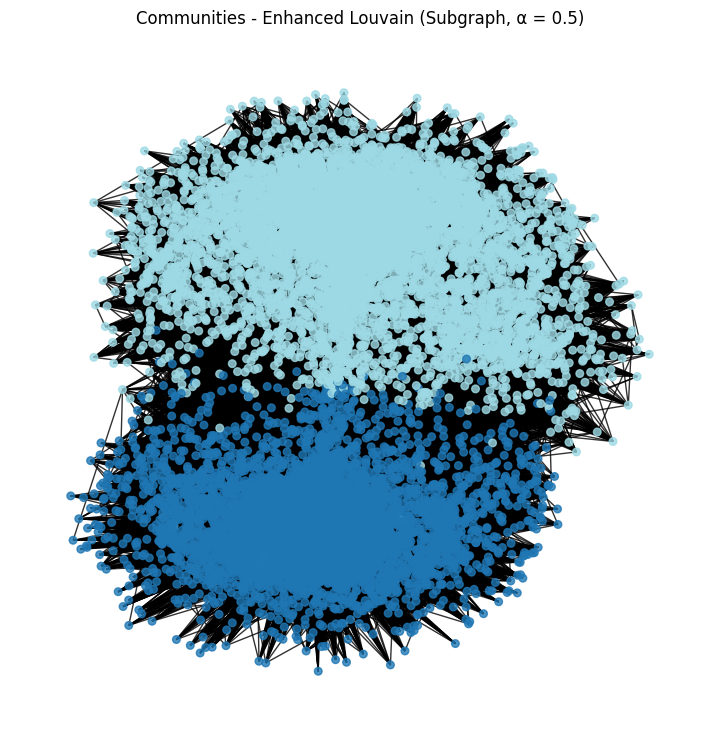

In [7]:
from collections import OrderedDict

def run_model_with_fallback(G: nx.Graph, b: Dict[Any, float], alpha: float,
                            prefer_num_communities=2, fallback_k=FALLBACK_K,
                            verbose=True):
    model = heuristic.EnhancedLouvainWithBias(alpha=alpha, verbose=verbose)
    try:
        model.fit(G, b, num_communities=prefer_num_communities)
    except TypeError as e:
        if verbose:
            print(f"[WARN] {e}. Retrying with num_communities={fallback_k} ...")
        model = heuristic.EnhancedLouvainWithBias(alpha=alpha, verbose=verbose)
        model.fit(G, b, num_communities=fallback_k)
    return model

print("🔧 Running heuristic at α = {ALPHA_FIXED}")
model_fixed = run_model_with_fallback(G, b_part, alpha=ALPHA_FIXED, prefer_num_communities=2)
partition_fixed = model_fixed.communities  # dict: node -> community id

metrics_fixed = evaluation.ComprehensiveEvaluator.evaluate_communities(
    G=G, partition=partition_fixed, bias_scores=b_part, ground_truth=gt
)
print("✅ Fixed-α results:")
for k, v in metrics_fixed.items():
    if isinstance(v, float):
        print(f"  {k}: {v:.4f}")
    else:
        print(f"  {k}: {v}")

metrics_fixed

# A partição está em `communities`
enhanced_partition = partition_fixed
print("Enhanced Louvain executado com sucesso.")
print("Exemplo de partição:", list(enhanced_partition.items())[:5])

# Visualização do subgrafo
sub_partition_enh = {n: enhanced_partition.get(n, -1) for n in sub_nodes}
colors_enh = [sub_partition_enh[n] for n in sub.nodes()]

plt.figure(figsize=(7, 7))
nx.draw(sub, pos, node_size=30, node_color=colors_enh, cmap='tab20', alpha=0.8)
plt.title("Communities - Enhanced Louvain (Subgraph, α = 0.5)")
plt.show()

## SDP Implementation

## 9. Imports

In [8]:
# We evaluate the heuristic on induced subgraphs of increasing size.
# We measure time, memory, and quality metrics at each step.

# %%
import os
import time
import math
import psutil
import logging
import numpy as np
import networkx as nx
from typing import List, Tuple

from src.twitter_dataset import (
    load_measures_tab,
    load_friends_graph,
    compute_bias_from_measures,    # uses only partisanship here
    generate_ground_truth          # you can ignore if not using gt
)
from src.sdp_model import BiasAwareSDP
from src.evaluation import ComprehensiveEvaluator  # modularity, ARI, NMI, intra-bias, etc.
DATA_DIR = PROJECT_ROOT / "TWITTER"
MEASURES_TAB = DATA_DIR / "measures.tab"
ANON_FRIENDS = DATA_DIR / "anonymized-friends.json"  # supports .json or .json.gz
ANON_SHARES  = DATA_DIR / "anonymized-shares.json"   # optional; not required for the heuristic itself

logging.getLogger("BiasAwareSDP").setLevel(logging.INFO)

def rss_gb() -> float:
    """Resident set size (GB) of the current process."""
    return psutil.Process(os.getpid()).memory_info().rss / (1024**3)


## 10. Benchmark Function

In [9]:
def induced_by_high_degree(G: nx.Graph, n: int) -> nx.Graph:
    """Takes the top-n highest-degree nodes and induces a subgraph."""
    deg = sorted(G.degree, key=lambda x: x[1], reverse=True)
    nodes = [u for u, _ in deg[:n]]
    return G.subgraph(nodes).copy()

def sdp_benchmark(
    G: nx.Graph,
    b: dict,
    sizes: List[int],
    alpha: float = 0.5,
    time_limit_s: float = 300.0,
    solver: str = "SCS",
    random_rounds: int = 32,
    eval_with_gt: bool = True,
    gt: dict | None = None
) -> List[Tuple[int, float, float, dict]]:
    """
    to each size n in `sizes`:
      - Induces high-degree top-n subgraph;
      - Runs 2-way SDP;
      - Measures time, memory, and metrics (Q, ARI, NMI, intra-bias).
    """
    results = []
    for n in sizes:
        if n > G.number_of_nodes():
            break
        G_n = induced_by_high_degree(G, n)
        b_n = {u: b[u] for u in G_n.nodes() if u in b}

        print(f"\n🚀 SDP em n={n}  (mem={rss_gb():.2f} GB)")
        model = BiasAwareSDP(
            alpha=alpha,
            solver=solver,
            max_iters=5_000,
            eps_abs=1e-4,
            eps_rel=1e-4,
            verbose=False,
            random_rounds=random_rounds
        )

        t0 = time.time()
        try:
            part = model.fit(G_n, b_n)
        except Exception as e:
            print(f"[FAIL] SDP falhou em n={n}: {e}")
            break
        runtime = time.time() - t0
        mem = rss_gb()

        # Evaluation
        try:
            metrics = ComprehensiveEvaluator.evaluate_communities(
                G=G_n,
                partition=part,
                bias_scores=b_n,
                ground_truth=gt
            )
        except Exception as e:
            print(f"[WARN] Falhou métricas: {e}")
            metrics = {}

        print(f"✅ n={n} | t={runtime:.1f}s | Q={metrics.get('modularity','-')}, "
              f"ARI={metrics.get('ari','-')}, NMI={metrics.get('nmi','-')}, "
              f"intra-bias={metrics.get('intra_bias','-')} | mem={mem:.2f} GB")

        results.append((n, runtime, mem, metrics))

        if runtime > time_limit_s:
            print(f"[STOP] Tempo excedeu {time_limit_s}s em n={n}.")
            break

    return results


## 11. Benchmark Run

In [10]:
# Adjust the size grid according to your machine/solver:
sizes = [500]
alpha = 0.5  # our default

bench = sdp_benchmark(
    G=G,
    b=b_part,
    sizes=sizes,
    alpha=alpha,
    time_limit_s=1200.0,   # 10 min per run (adjust if you have MOSEK/more RAM)
    solver="SCS",         # change to "MOSEK" if available
    random_rounds=64,
    eval_with_gt=(gt is not None),
    gt=gt
)

# Decides the maximum n solved within the time limit
n_max = max((n for (n, t, m, _) in bench), default=0)
print(f"\n📌 Max n solved in time: {n_max}")


2025-12-08 13:25:51,146 | INFO    | 🔷 Solving SDP (n=500, solver=SCS) ...
13:25:51 | INFO     | 🔷 Solving SDP (n=500, solver=SCS) ...



🚀 SDP em n=500  (mem=2.97 GB)


2025-12-08 13:33:27,711 | INFO    | ✅ SDP solved in 456.71s | objective=-13230.454306
13:33:27 | INFO     | ✅ SDP solved in 456.71s | objective=-13230.454306
13:33:27 | INFO     | 🧩 Evaluating community partition...
13:33:27 | INFO     | ✅ Evaluation completed — Q=0.098, ARI=0.626, NMI=0.573, intra-bias=0.241


✅ n=500 | t=456.7s | Q=0.0977881552624982, ARI=-, NMI=-, intra-bias=- | mem=3.03 GB

📌 Max n solved in time: 500
